# Airplane Detection with YOLOv8l
**Config:** YOLOv8l + imgsz=960 + AdamW + 30 epochs + augmentation  
*(Experiment #32 from RSandAI/Efficient-YOLO-RS-Airplane-Detection)*

## Install dependencies

In [26]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.52 🚀 Python-3.13.12 torch-2.11.0+cu126 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
Setup complete ✅ (80 CPUs, 754.5 GB RAM, 3460.3/4434.8 GB disk)


## Prepare dataset config (YAML)

In [27]:
import os, yaml

# Paths are relative to this notebook's directory
DATASET_YAML = 'hrplanes.yaml'
MODEL_WEIGHTS = 'runs/detect/hrplanes_v8l/weights/best.pt'

dataset_cfg = {
    'path': '.',                          # root = notebook directory
    'train': 'data/plane/train.txt',
    'val':   'data/plane/val.txt',
    'test':  'data/plane/test.txt',
    'nc': 1,
    'names': ['Plane'],
}

# Validation split file is named val.txt by YOLO convention;
# symlink/copy if your file is named validation.txt
val_src = 'data/plane/validation.txt'
val_dst = 'data/plane/val.txt'
if os.path.exists(val_src) and not os.path.exists(val_dst):
    import shutil
    shutil.copy(val_src, val_dst)

# Copy split lists to expected location if they live next to the notebook
for src, dst in [('train.txt', 'data/plane/train.txt'),
                 ('validation.txt', 'data/plane/val.txt'),
                 ('test.txt', 'data/plane/test.txt')]:
    if os.path.exists(src) and not os.path.exists(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        import shutil; shutil.copy(src, dst)

with open(DATASET_YAML, 'w') as f:
    yaml.dump(dataset_cfg, f, default_flow_style=False)

print('Dataset YAML written:')
print(open(DATASET_YAML).read())

Dataset YAML written:
names:
- Plane
nc: 1
path: .
test: data/plane/test.txt
train: data/plane/train.txt
val: data/plane/val.txt



## Prepare labels (symlink img/*.txt → labels/*.txt)

In [28]:
from pathlib import Path
from tqdm import tqdm

img_dir   = Path('data/plane/img')
label_dir = Path('data/plane/labels')
label_dir.mkdir(parents=True, exist_ok=True)

txt_files = list(img_dir.glob('*.txt'))
skipped = created = 0

for src in tqdm(txt_files, desc='Linking labels'):
    dst = label_dir / src.name
    if dst.exists() or dst.is_symlink():
        skipped += 1
        continue
    dst.symlink_to(src.resolve())
    created += 1

print(f'Done: {created} symlinks created, {skipped} already existed.')
print(f'Total label files in labels/: {len(list(label_dir.iterdir()))}')

Linking labels:   0%|          | 0/3093 [00:00<?, ?it/s]

Linking labels: 100%|██████████| 3093/3093 [00:00<00:00, 60782.46it/s]

Done: 0 symlinks created, 3093 already existed.
Total label files in labels/: 3093


## Train (skip if best.pt already exists)

In [ ]:
from ultralytics import YOLO
from pathlib import Path

if Path(MODEL_WEIGHTS).exists():
    print(f'Saved model found at {MODEL_WEIGHTS} - skipping training.')
else:
    model = YOLO('yolov8l.pt')  # pretrained COCO weights

    results = model.train(
        data=DATASET_YAML,
        epochs=30,
        imgsz=960,
        batch=16,
        optimizer='AdamW',
        lr0=0.001,
        # Augmentation (exp #32 params)
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        mosaic=1.0,
        # Output
        project='runs/detect',
        name='hrplanes_v8l',
        exist_ok=True,
        # Progress & logging
        verbose=True,
        plots=True,
        save=True,
        save_period=-1,   # save only best & last
    )
    print('Training complete.')

Saved model found at runs/detect/hrplanes_v8l/weights/best.pt - skipping training.


## 5. Training curves

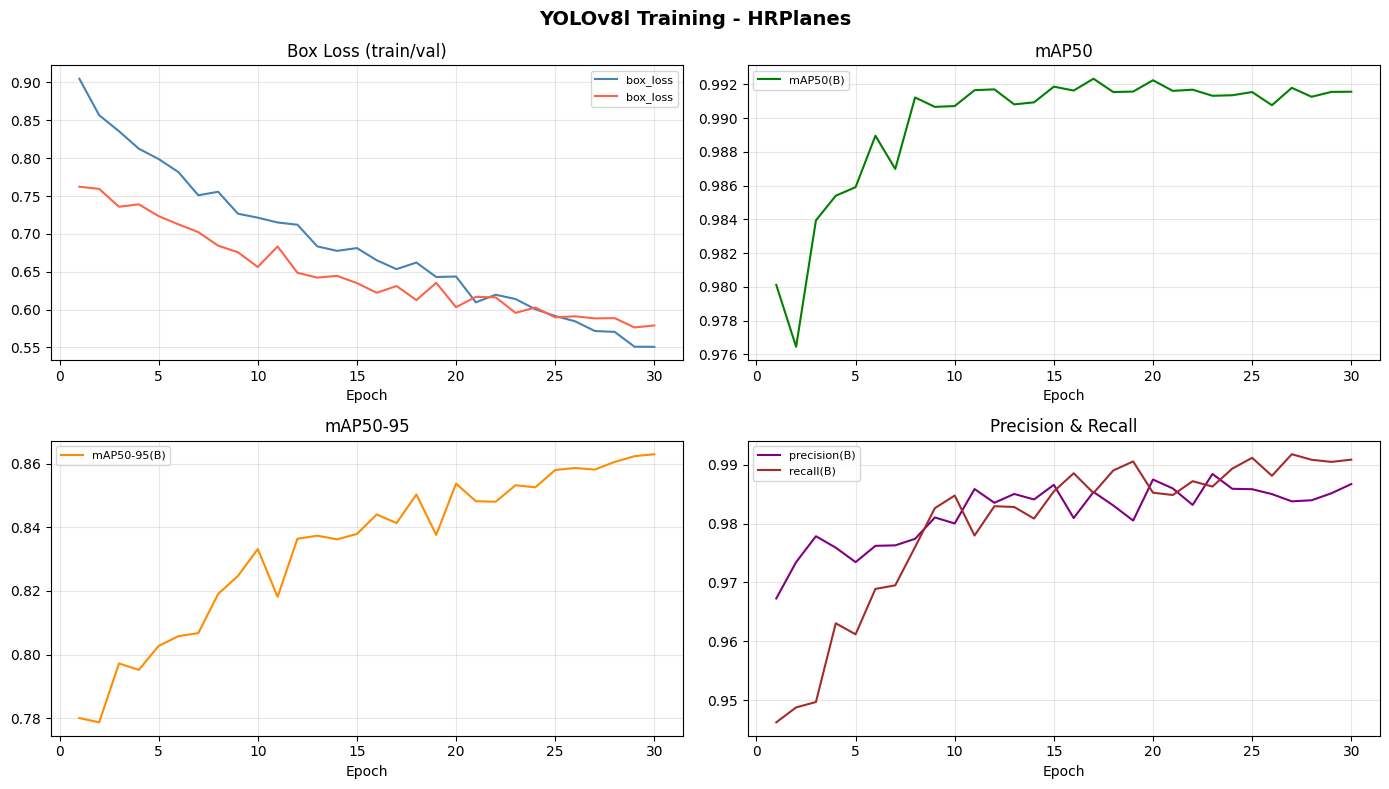

In [30]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

results_csv = Path('runs/detect/hrplanes_v8l/results.csv')
if not results_csv.exists():
    print('No results.csv found - run training first.')
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    metrics = {
        'Box Loss (train/val)': (['train/box_loss', 'val/box_loss'], ['steelblue', 'tomato']),
        'mAP50':               (['metrics/mAP50(B)'],               ['green']),
        'mAP50-95':            (['metrics/mAP50-95(B)'],            ['darkorange']),
        'Precision & Recall':  (['metrics/precision(B)', 'metrics/recall(B)'], ['purple', 'brown']),
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('YOLOv8l Training - HRPlanes', fontsize=14, fontweight='bold')

    for ax, (title, (cols, colors)) in zip(axes.flatten(), metrics.items()):
        for col, color in zip(cols, colors):
            if col in df.columns:
                ax.plot(df['epoch'], df[col], label=col.split('/')[-1], color=color)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('runs/detect/hrplanes_v8l/training_curves.png', dpi=150)
    plt.show()

## 6. Evaluate on test set

In [31]:
from ultralytics import YOLO

model = YOLO(MODEL_WEIGHTS)

test_results = model.val(
    data=DATASET_YAML,
    split='test',
    imgsz=960,
    batch=16,
    verbose=True,
)

# Print metrics
p  = test_results.box.mp          # mean precision
r  = test_results.box.mr          # mean recall
f1 = 2 * p * r / (p + r + 1e-9)
m50   = test_results.box.map50
m5095 = test_results.box.map

print('\n' + '='*48)
print(f'  Test results (YOLOv8l, imgsz=960)')
print('='*48)
print(f'  F1 Score   : {f1:.4f}')
print(f'  Precision  : {p:.4f}')
print(f'  Recall     : {r:.4f}')
print(f'  mAP50      : {m50:.4f}')
print(f'  mAP50-95   : {m5095:.4f}')
print('='*48)

Ultralytics 8.4.52 🚀 Python-3.13.12 torch-2.11.0+cu126 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3746.6±159.7 MB/s, size: 4150.4 KB)
val: Scanning data/plane/img.cache... 310 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 311/311 68.7Mit/s 0.0s
val: data/plane/img/JOH_034.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'data/plane/img/JOH_034.jpg'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.1it/s 9.5s0.4s
                   all        310       1924      0.989      0.984      0.994      0.864
Speed: 1.9ms preprocess, 19.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /home/t.gritsenko/AIlabs/runs/detect/val-3

  Test results (YOLOv8l, imgsz=960)
  F1 Score   : 0.9865
  Precision  : 0.9890
  Recall     : 0.9841
  mAP50      : 0.9938
 

## 7. Single-image inference

Inference: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]


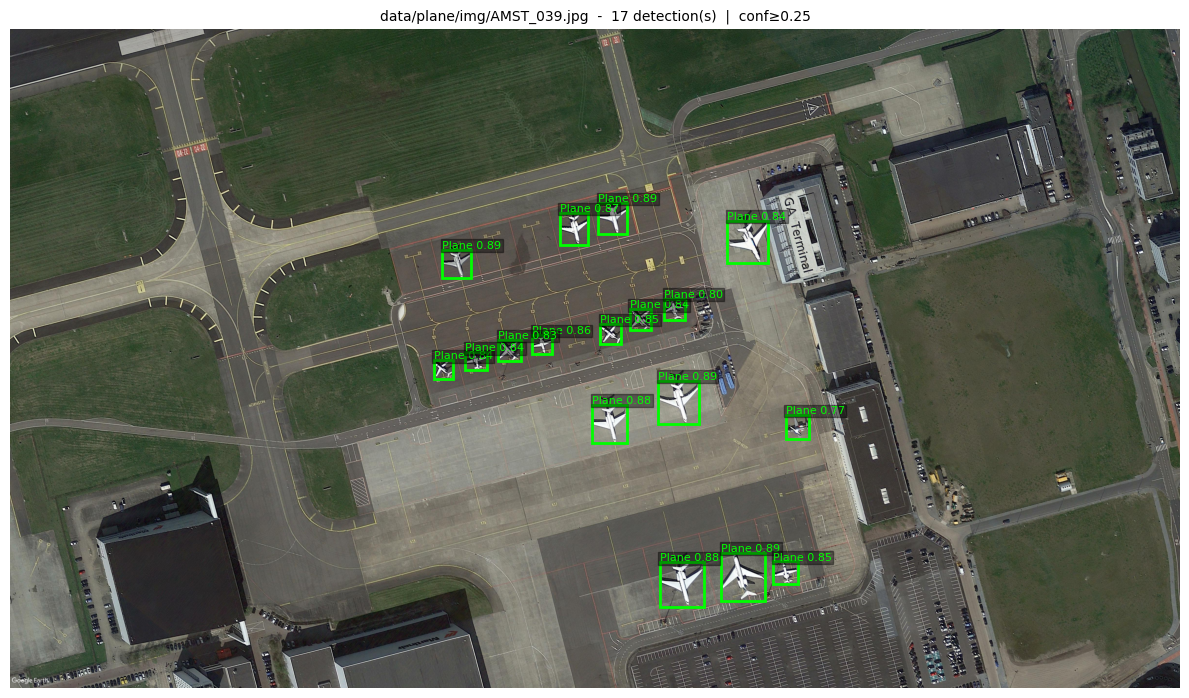

Detected 17 plane(s)
  [1] conf=0.891  bbox=(2413,712,2533,838)
  [2] conf=0.887  bbox=(1773,905,1889,1021)
  [3] conf=0.887  bbox=(2917,2147,3098,2345)
  [4] conf=0.885  bbox=(2658,1441,2826,1619)
  [5] conf=0.881  bbox=(2665,2186,2845,2370)
  [6] conf=0.876  bbox=(2388,1541,2532,1697)
  [7] conf=0.870  bbox=(2254,754,2371,885)
  [8] conf=0.861  bbox=(2141,1255,2222,1332)
  [9] conf=0.849  bbox=(2421,1209,2507,1290)
  [10] conf=0.846  bbox=(3130,2183,3231,2277)
  [11] conf=0.841  bbox=(2941,785,3109,958)
  [12] conf=0.841  bbox=(1737,1358,1818,1435)
  [13] conf=0.839  bbox=(2542,1149,2629,1235)
  [14] conf=0.835  bbox=(1867,1325,1957,1398)
  [15] conf=0.832  bbox=(2003,1274,2094,1362)
  [16] conf=0.797  bbox=(2683,1105,2767,1194)
  [17] conf=0.770  bbox=(3182,1582,3278,1683)


In [32]:
%matplotlib inline
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from tqdm import tqdm

IMAGE_PATH = 'data/plane/img/AMST_039.jpg'   # <-- image path
CONF_THRESH = 0.25

model = YOLO(MODEL_WEIGHTS)

for img_path in tqdm([IMAGE_PATH], desc='Inference'):
    preds = model.predict(
        source=img_path,
        imgsz=960,
        conf=CONF_THRESH,
        verbose=False,
    )

result = preds[0]
img = Image.open(IMAGE_PATH).convert('RGB')

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(np.array(img))

boxes = result.boxes
for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    conf = float(box.conf[0])
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 4, f'Plane {conf:.2f}',
            color='lime', fontsize=8,
            bbox=dict(facecolor='black', alpha=0.4, pad=1))

ax.set_title(f'{IMAGE_PATH}  -  {len(boxes)} detection(s)  |  conf≥{CONF_THRESH}',
             fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Detected {len(boxes)} plane(s)')
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    print(f'  [{i+1}] conf={float(box.conf[0]):.3f}  bbox=({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})')